In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [5]:
import seaborn as sns

df = sns.load_dataset("geyser")

print(df.head())
print(df.shape)

   duration  waiting   kind
0     3.600       79   long
1     1.800       54  short
2     3.333       74   long
3     2.283       62  short
4     4.533       85   long
(272, 3)


In [6]:
X = df[['waiting', 'duration']]

print(X.head())

   waiting  duration
0       79     3.600
1       54     1.800
2       74     3.333
3       62     2.283
4       85     4.533


In [7]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X)

print(df.head())

   duration  waiting   kind  Cluster
0     3.600       79   long        0
1     1.800       54  short        1
2     3.333       74   long        0
3     2.283       62  short        1
4     4.533       85   long        0


In [8]:
print("Cluster Centers:")
print(kmeans.cluster_centers_)

Cluster Centers:
[[80.28488372  4.29793023]
 [54.75        2.09433   ]]


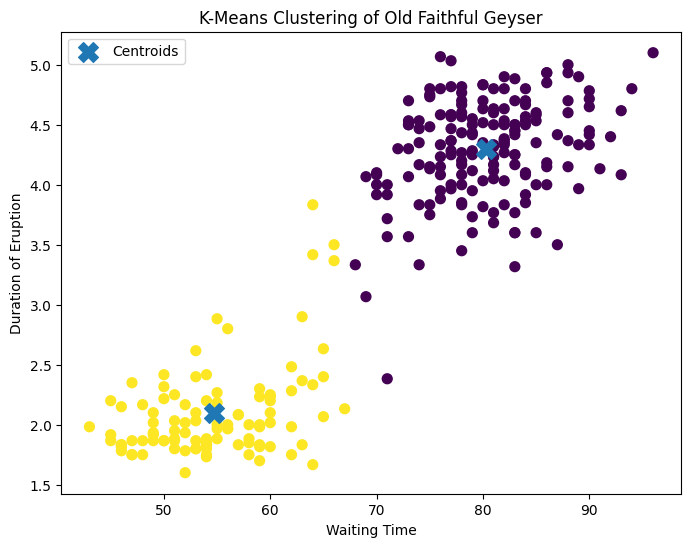

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['waiting'],
    df['duration'],
    c=df['Cluster'],
    s=50
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel("Waiting Time")
plt.ylabel("Duration of Eruption")
plt.title("K-Means Clustering of Old Faithful Geyser")
plt.legend()
plt.show()

In [10]:
for cluster in sorted(df['Cluster'].unique()):
    print("\nCluster", cluster)
    print(df[df['Cluster'] == cluster][['waiting', 'duration']])


Cluster 0
     waiting  duration
0         79     3.600
2         74     3.333
4         85     4.533
6         88     4.700
7         85     3.600
..       ...       ...
263       83     4.250
266       75     4.750
267       81     4.117
269       90     4.417
271       74     4.467

[172 rows x 2 columns]

Cluster 1
     waiting  duration
1         54     1.800
3         62     2.283
5         55     2.883
8         51     1.950
10        54     1.833
..       ...       ...
262       58     1.850
264       43     1.983
265       60     2.250
268       46     2.150
270       46     1.817

[100 rows x 2 columns]


In [11]:
print(df['Cluster'].value_counts())

Cluster
0    172
1    100
Name: count, dtype: int64
